# Double Responses in a Racing Diffusion Model
## BayesFlow parameter-recovery comparison

This notebook implements a **small, simulation-only project inspired by Evans et al. (2020)**.

### Main question

> Do double responses provide additional information for recovering the hidden parameters of an evidence accumulation model?

We compare two BayesFlow inference systems trained on data from the **same Racing Diffusion Model (RDM)**:

1. **Single-response inference** sees only the initial choice and response time.
2. **Double-response inference** additionally sees whether a double response occurred and its latency.

Because the simulator and parameters are identical in both analyses, any recovery difference is caused by the additional double-response observations.

### Deliberate simplifications

This is **not** a full reproduction of the paper. We use:

- one RDM rather than the paper's tree of nine EAM variants;
- one condition and one synthetic participant per simulated dataset;
- five parameters: starting-point range, threshold separation, non-decision time, correct drift, and error drift;
- fixed within-trial noise scale of 1;
- no lateral inhibition, leakage, or between-trial drift/non-decision variability;
- the paper's primary double-response rule: the losing accumulator reaches its threshold within 250 ms after the first response.

The supplied original files were used to identify the model structure, especially:

- `Code/BTV_RDM_withDR.c`
- `Code/BTV_simulate-RDM_withDR.R`
- `Exp1/newDoubleResp_RDM.R`
- `Exp1/onlyRTs_RDM.R`

**Reference:** Evans, N. J., Dutilh, G., Wagenmakers, E.-J., & van der Maas, H. L. (2020). *Double responding: A new constraint for models of speeded decision making*. Cognitive Psychology, 121, 101292. https://doi.org/10.1016/j.cogpsych.2020.101292

## 1. Workflow

The notebook follows this sequence:

1. Define parameter priors.
2. Simulate RDM choices, response times, and double responses.
3. Generate many parameter–dataset pairs.
4. Train one BayesFlow posterior estimator using only single-response information.
5. Train a second estimator using the additional double-response information.
6. Test both estimators on the **same unseen simulated datasets**.
7. Compare posterior-mean RMSE, 95% interval coverage, and interval width.
8. Optionally inspect one participant from the supplied RData file.

## 2. Installation

BayesFlow 2 requires a Keras backend. This notebook uses the **JAX backend** through Keras.

Run the installation cell once. If the packages are installed for the first time, restart the kernel before continuing.

In [ ]:
%pip install -q \
    "bayesflow==2.0.12" \
    "keras>=3.12,<4" \
    "jax[cpu]>=0.5" \
    "rdata>=1.0" \
    "numpy>=2.2,<3" \
    "pandas>=2.3,<4" \
    "scipy>=1.15,<2" \
    "matplotlib>=3.10,<4"

## 3. Imports and reproducibility

The backend environment variable must be set **before** importing Keras or BayesFlow.

In [ ]:
import os

# Set the backend before importing Keras or BayesFlow.
os.environ["KERAS_BACKEND"] = "jax"

import numpy as np
import pandas as pd
import scipy
import matplotlib
import matplotlib.pyplot as plt
import keras
import jax
import bayesflow as bf
import rdata

SEED = 20260717

np.random.seed(SEED)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Keras:", keras.__version__)
print("JAX:", jax.__version__)
print("BayesFlow:", bf.__version__)
print("Keras backend:", keras.backend.backend())

INFO:bayesflow:Using backend 'jax'


NumPy: 2.5.1
Pandas: 3.0.3
SciPy: 1.16.3
Matplotlib: 3.11.1
Keras: 3.13.2
JAX: 0.7.2
BayesFlow: 2.0.12
Keras backend: jax


## 4. Computation profile

The notebook provides two computation profiles.

- `FAST_MODE=True` uses a small simulation bank and only a few training epochs. It is intended for debugging and verifying that the complete workflow runs successfully.
- `FAST_MODE=False` uses substantially more simulated datasets, trials, training epochs, and posterior samples and is intended for the main parameter-recovery experiment.

Results obtained with `FAST_MODE=True` should be treated as illustrative rather than as stable parameter-recovery estimates.

In [ ]:
FAST_MODE = True

if FAST_MODE:
    N_TRIALS = 300
    N_TRAIN_DATASETS = 300
    Validation = 60
    N_TEST_DATASETS = 40
    EPOCHS = 5
    BATCH_SIZE = 64
    N_POSTERIOR_SAMPLES = 250
else:
    N_TRIALS = 2_000
    N_TRAIN_DATASETS = 5_000
    Validation = 500
    N_TEST_DATASETS = 250
    EPOCHS = 150
    BATCH_SIZE = 128
    N_POSTERIOR_SAMPLES = 2_000

DOUBLE_RESPONSE_WINDOW = 0.250  # seconds, as in Experiment 1
SUMMARY_DIM = 16

config = pd.Series({
    "FAST_MODE": FAST_MODE,
    "trials per dataset": N_TRIALS,
    "training datasets": N_TRAIN_DATASETS,
    "test datasets": N_TEST_DATASETS,
    "epochs per BayesFlow model": EPOCHS,
    "batch size": BATCH_SIZE,
    "posterior samples per test dataset": N_POSTERIOR_SAMPLES,
    "double-response window (s)": DOUBLE_RESPONSE_WINDOW,
})
config.to_frame("value")

,value
FAST_MODE,True
trials per dataset,300
training datasets,300
test datasets,40
epochs per BayesFlow model,5
batch size,64
posterior samples per test dataset,250
double-response window (s),0.25


# Part A — Scientific Model and Simulator

## 5. Simplified Racing Diffusion Model

The model contains two independent evidence accumulators:

- accumulator 0 supports the **correct** response;
- accumulator 1 supports the **error** response.

For accumulator $i$, the evidence evolves according to:

$$
dx_i(t) = v_i\,dt + dW_i(t),
$$

where $v_i$ is the drift rate and $dW_i(t)$ represents independent Gaussian diffusion noise with scale $1$.

For each trial, the initial evidence is sampled as:

$$
x_i(0) \sim \mathrm{Uniform}(0,A),
$$

and both accumulators race toward the common response threshold:

$$
B = A + b.
$$

Let $T_c$ and $T_e$ denote the threshold-crossing times of the correct and error accumulators, respectively.

The first decision time is:

$$
T_{\mathrm{decision}} = \min(T_c,T_e).
$$

The accumulator that reaches the threshold first determines whether the initial response is correct or incorrect.

The observed first-response time is:

$$
RT = \min(T_c,T_e) + t_0,
$$

where $t_0$ represents non-decision time.

A double response occurs when the losing accumulator also reaches the threshold within the $250\,\mathrm{ms}$ post-response window:

$$
DR =
\mathbb{1}
\left(
0 < |T_c-T_e| \leq 0.250
\right).
$$

For double-response trials, the double-response latency is:

$$
DRT = |T_c-T_e|.
$$

The original paper approximated the evidence trajectories using **5 ms Euler steps**. For the independent RDM implemented in this notebook, each threshold-crossing time has a known inverse-Gaussian distribution. Therefore, the crossing times are sampled directly from their **exact continuous-time first-passage-time distributions**.

This avoids time discretization while representing the same underlying independent drift-diffusion process and substantially reduces the computational cost of generating the large simulation bank required for BayesFlow.

## 6. Parameters and priors

The prior ranges are broad teaching priors, not estimates from the real participants. They deliberately produce more double responses than the empirical paper data so that the added information is visible with only a few hundred trials per simulated dataset.

| Parameter | Meaning | Prior |
|---|---|---|
| \(A\) | Width of uniform starting evidence | Uniform(0.20, 0.90) |
| \(b\) | Distance above \(A\) to the threshold | Uniform(1.00, 2.80) |
| \(t_0\) | Non-decision time in seconds | Uniform(0.15, 0.35) |
| \(v_e\) | Error-accumulator drift | Uniform(0.05, 1.10) |
| \(v_c-v_e\) | Correct-over-error drift advantage | Uniform(0.70, 3.20) |

We infer \(v_c\) and \(v_e\), while sampling them in a way that guarantees \(v_c>v_e\).

In [ ]:
PARAMETER_NAMES = ["A", "b", "t0", "v_correct", "v_error"]
PARAMETER_LABELS = [r"$A$", r"$b$", r"$t_0$", r"$v_c$", r"$v_e$"]


def sample_prior(n_datasets: int, rng: np.random.Generator) -> np.ndarray:
    """Sample parameter vectors from the teaching priors.

    Parameters
    ----------
    n_datasets:
        Number of independent synthetic datasets to parameterize.
    rng:
        NumPy random-number generator.

    Returns
    -------
    parameters:
        Array with shape ``(n_datasets, 5)`` ordered as
        ``[A, b, t0, v_correct, v_error]``.
    """
    A = rng.uniform(0.20, 0.90, size=n_datasets) # starting point
    b = rng.uniform(1.00, 2.80, size=n_datasets) # threshold
    t0 = rng.uniform(0.15, 0.35, size=n_datasets) # non_decision
    v_error = rng.uniform(0.05, 1.10, size=n_datasets) # error drift rate
    drift_advantage = rng.uniform(0.70, 3.20, size=n_datasets) # advantage

    v_correct = v_error + drift_advantage

    return np.column_stack([A, b, t0, v_correct, v_error]).astype(np.float32)

In [ ]:
def validate_parameters(parameters: np.ndarray) -> np.ndarray:
    """Validate and standardize an RDM parameter array."""
    parameters = np.asarray(parameters, dtype=np.float64)

    if parameters.ndim == 1:
        parameters = parameters[None, :]
    if parameters.ndim != 2 or parameters.shape[1] != len(PARAMETER_NAMES):
        raise ValueError(
            f"Expected shape (n_datasets, {len(PARAMETER_NAMES)}), "
            f"received {parameters.shape}."
        )
    if not np.isfinite(parameters).all():
        raise ValueError("All parameter values must be finite.")
    if (parameters <= 0).any():
        raise ValueError("All simplified RDM parameters must be positive.")
    if (parameters[:, 3] <= parameters[:, 4]).any():
        raise ValueError("v_correct must be larger than v_error.")

    return parameters

## 7. Vectorized RDM Simulator

For a Brownian accumulator with positive drift $v$, diffusion scale $1$, and remaining threshold distance $d$, the first-passage time follows an inverse Gaussian distribution:

$$
T \sim IG\left(
\mu=\frac{d}{v},
\lambda=d^2
\right)
$$

NumPy provides this distribution through:

```python
rng.wald(mean, scale)

The original paper code approximated the trajectories with 5 ms Euler steps. This teaching notebook instead samples the **exact continuous-time first-passage time** for each independent accumulator. For this simplified independent RDM, that represents the same diffusion process without time discretization and makes the large simulation bank much faster. The double-response latency is the difference between the losing and winning threshold-crossing times.

In [ ]:
def simulate_rdm_batch(
    parameters: np.ndarray,
    n_trials: int,
    rng: np.random.Generator,
    double_response_window: float = 0.250,
) -> tuple[np.ndarray, np.ndarray]:
    """Simulate many independent RDM datasets at once.

    Parameters
    ----------
    parameters:
        Array of shape ``(n_datasets, 5)`` containing
        ``[A, b, t0, v_correct, v_error]``.
    n_trials:
        Number of exchangeable trials in each dataset.
    rng:
        NumPy random-number generator.
    double_response_window:
        Maximum time between the first and second threshold crossings.

    Returns
    -------
    single_trials:
        Shape ``(n_datasets, n_trials, 2)`` with columns
        ``[correct, first_rt]``.
    double_trials:
        Shape ``(n_datasets, n_trials, 4)`` with columns
        ``[correct, first_rt, double_response, double_response_latency]``.
        Latency is set to zero when no double response occurs; the indicator
        distinguishes a true latency from this placeholder.
    """
    parameters = validate_parameters(parameters)
    if n_trials < 1:
        raise ValueError("n_trials must be at least 1.")
    if double_response_window <= 0:
        raise ValueError("double_response_window must be positive.")

    n_datasets = parameters.shape[0]
    A, b, t0, v_correct, v_error = parameters.T

    # Independent trial-specific starting evidence for both accumulators.
    starting_evidence = (
        rng.uniform(size=(n_datasets, n_trials, 2)) * A[:, None, None]
    )

    threshold = (A + b)[:, None, None]
    distance_to_threshold = threshold - starting_evidence
    drifts = np.stack([v_correct, v_error], axis=1)[:, None, :]

    # Exact first-passage-time sampling for independent drift diffusions.
    mean_fpt = distance_to_threshold / drifts
    scale_fpt = distance_to_threshold**2
    hitting_times = rng.wald(mean=mean_fpt, scale=scale_fpt)

    first_choice = np.argmin(hitting_times, axis=-1)
    first_decision_time = np.min(hitting_times, axis=-1)
    losing_hitting_time = np.max(hitting_times, axis=-1)

    double_latency = losing_hitting_time - first_decision_time
    double_response = double_latency <= double_response_window

    correct = first_choice == 0
    first_rt = first_decision_time + t0[:, None]

    single_trials = np.stack(
        [correct.astype(np.float32), first_rt.astype(np.float32)], axis=-1
    )
    double_trials = np.stack(
        [
            correct.astype(np.float32),
            first_rt.astype(np.float32),
            double_response.astype(np.float32),
            np.where(double_response, double_latency, 0.0).astype(np.float32),
        ],
        axis=-1,
    )

    return single_trials, double_trials

## 8. Descriptive summary helpers

In [ ]:
def safe_conditional_mean(values: np.ndarray, mask: np.ndarray) -> float:
    """Return a conditional mean, or NaN when the condition never occurs."""
    return float(np.mean(values[mask])) if np.any(mask) else np.nan


def summarize_trials(double_trials: np.ndarray) -> pd.Series:
    """Calculate interpretable behavioral summaries for one dataset."""
    trials = np.asarray(double_trials)
    if trials.ndim != 2 or trials.shape[1] != 4:
        raise ValueError("Expected one dataset with shape (n_trials, 4).")

    correct = trials[:, 0].astype(bool)
    rt = trials[:, 1]
    double = trials[:, 2].astype(bool)
    latency = trials[:, 3]

    return pd.Series({
        "n_trials": len(trials),
        "accuracy": correct.mean(),
        "mean_RT_s": rt.mean(),
        "median_RT_s": np.median(rt),
        "double_response_rate": double.mean(),
        "P(DR | correct)": safe_conditional_mean(double, correct),
        "P(DR | error)": safe_conditional_mean(double, ~correct),
        "median_DR_latency_s": (
            float(np.median(latency[double])) if np.any(double) else np.nan
        ),
    })

## 9. Simulate one synthetic participant

This is a forward simulation with known parameters. It checks that the simulator produces sensible choices, response times, and double responses before any neural inference is attempted.

In [ ]:
demo_parameters = np.array(
    [[0.50, 1.60, 0.23, 2.70, 0.75]],
    dtype=np.float32,
)

demo_single, demo_double = simulate_rdm_batch(
    parameters=demo_parameters,
    n_trials=2_000,
    rng=np.random.default_rng(SEED + 1),
    double_response_window=DOUBLE_RESPONSE_WINDOW,
)

pd.DataFrame(
    demo_parameters,
    columns=PARAMETER_NAMES,
    index=["true value"],
)

,A,b,t0,v_correct,v_error
true value,0.5,1.6,0.23,2.7,0.75


In [ ]:
summarize_trials(demo_double[0]).to_frame("value")

,value
n_trials,2000.000000
accuracy,0.900000
mean_RT_s,0.890633
median_RT_s,0.833394
double_response_rate,0.138000
P(DR | correct),0.095000
P(DR | error),0.525000
median_DR_latency_s,0.125238


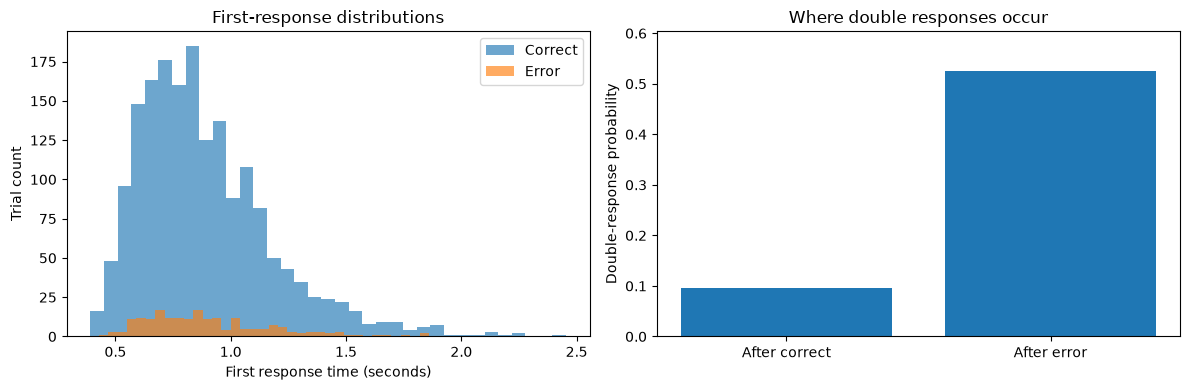

In [ ]:
def plot_demo_behavior(double_trials: np.ndarray) -> None:
    """Plot first-response distributions and conditional double-response rates."""
    correct = double_trials[:, 0].astype(bool)
    rt = double_trials[:, 1]
    double = double_trials[:, 2].astype(bool)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(rt[correct], bins=35, alpha=0.65, label="Correct")
    axes[0].hist(rt[~correct], bins=35, alpha=0.65, label="Error")
    axes[0].set_xlabel("First response time (seconds)")
    axes[0].set_ylabel("Trial count")
    axes[0].set_title("First-response distributions")
    axes[0].legend()

    conditional_rates = [
        safe_conditional_mean(double, correct),
        safe_conditional_mean(double, ~correct),
    ]
    axes[1].bar(["After correct", "After error"], conditional_rates)
    axes[1].set_ylabel("Double-response probability")
    axes[1].set_ylim(0, max(0.05, np.nanmax(conditional_rates) * 1.15))
    axes[1].set_title("Where double responses occur")

    fig.tight_layout()
    plt.show()


plot_demo_behavior(demo_double[0])

# Part B — Optional inspection of the supplied RData

This section is descriptive only. The BayesFlow recovery comparison below uses simulated data, which is sufficient for the project goal.

The paper's parser stores:

- `Correct`: whether the initial response was correct;
- `Time1`: first response time in seconds;
- `DoubleResp`: whether the opposite key was subsequently pressed;
- `Time2`: delay from the first to the second response in seconds, missing when there was no double response.

In [ ]:
from pathlib import Path


def locate_rdata_file() -> Path | None:
    """Locate the uploaded RData file in the Colab working directory."""
    candidates = [
        Path("/content/parsedData_doubleResp.Rdata"),
        Path("parsedData_doubleResp.Rdata"),
    ]
    return next((path for path in candidates if path.exists()), None)


def load_evans_rdata(path: Path):
    """Load the paper's RData object using the pure-Python rdata package."""
    import rdata

    parsed = rdata.parser.parse_file(path)
    return rdata.conversion.convert(parsed)


RDATA_PATH = locate_rdata_file()

if RDATA_PATH is None:
    raise FileNotFoundError(
        "parsedData_doubleResp.Rdata was not found in the Colab folder."
    )

print("RData path:", RDATA_PATH)

evans_data = load_evans_rdata(RDATA_PATH)

RData path: /content/parsedData_doubleResp.Rdata


In [ ]:
def summarize_rdata_participants(r_object: dict) -> pd.DataFrame:
    """Create the Experiment 1 participant summary used for a sanity check."""
    rows = []

    for participant_id, participant in enumerate(r_object["data"], start=1):
        correct = np.asarray(participant["Correct"], dtype=bool)
        rt = np.asarray(participant["Time1"], dtype=float)
        double = np.asarray(participant["DoubleResp"], dtype=bool)
        latency = np.asarray(participant["Time2"], dtype=float)

        rows.append({
            "participant": participant_id,
            "n_trials": len(rt),
            "mean_RT_s": np.nanmean(rt),
            "accuracy": correct.mean(),
            "double_response_rate": double.mean(),
            "P(DR | correct)": safe_conditional_mean(double, correct),
            "P(DR | error)": safe_conditional_mean(double, ~correct),
            "median_DR_latency_s": (
                np.nanmedian(latency[double]) if np.any(double) else np.nan
            ),
        })

    return pd.DataFrame(rows)


if RDATA_PATH is not None:
    evans_rdata = load_evans_rdata(RDATA_PATH)
    display(summarize_rdata_participants(evans_rdata))
else:
    print("RData file not found. The simulation study can still run normally.")

,participant,n_trials,mean_RT_s,accuracy,double_response_rate,P(DR | correct),P(DR | error),median_DR_latency_s
0,1,10000,0.434810,0.7344,0.0191,0.003676,0.061747,0.0774
1,2,10000,0.493316,0.8252,0.0255,0.003878,0.127574,0.0854
2,3,10000,0.567845,0.9480,0.0003,0.000000,0.005769,0.0540
3,4,10000,0.529592,0.9286,0.0007,0.000000,0.009804,0.0301


# Part C — Generate the BayesFlow simulation bank

## 10. Generate many parameter–dataset pairs

For every synthetic dataset, we know the true parameters because we sampled them ourselves. These known pairs provide the supervision for amortized posterior estimation.

In [ ]:
def generate_simulation_bank(
    n_datasets: int,
    n_trials: int,
    seed: int,
    chunk_size: int = 1_000,
) -> dict[str, np.ndarray]:
    """Generate parameters and both observation versions in memory.

    Chunking limits temporary memory usage while retaining vectorized simulation.
    """
    rng = np.random.default_rng(seed)
    parameters = sample_prior(n_datasets, rng)

    single_trials = np.empty((n_datasets, n_trials, 2), dtype=np.float32)
    double_trials = np.empty((n_datasets, n_trials, 4), dtype=np.float32)

    for start in range(0, n_datasets, chunk_size):
        stop = min(start + chunk_size, n_datasets)
        single_chunk, double_chunk = simulate_rdm_batch(
            parameters=parameters[start:stop],
            n_trials=n_trials,
            rng=rng,
            double_response_window=DOUBLE_RESPONSE_WINDOW,
        )
        single_trials[start:stop] = single_chunk
        double_trials[start:stop] = double_chunk

    return {
        "parameters": parameters,
        "single_trials": single_trials,
        "double_trials": double_trials,
    }

In [ ]:
train_bank = generate_simulation_bank(
    n_datasets=N_TRAIN_DATASETS,
    n_trials=N_TRIALS,
    seed=SEED + 10,
)

test_bank = generate_simulation_bank(
    n_datasets=N_TEST_DATASETS,
    n_trials=N_TRIALS,
    seed=SEED + 20,
)

shape_summary = pd.DataFrame({
    "train shape": {key: value.shape for key, value in train_bank.items()},
    "test shape": {key: value.shape for key, value in test_bank.items()},
})
shape_summary

,train shape,test shape
parameters,"(300, 5)","(40, 5)"
single_trials,"(300, 300, 2)","(40, 300, 2)"
double_trials,"(300, 300, 4)","(40, 300, 4)"


## 11. Check the prior-predictive behavior

Before training, verify that the priors produce a useful variety of behavior. The double-response rate should vary across datasets; otherwise, double responses cannot add much information.

In [ ]:
def bank_behavior_summary(bank: dict[str, np.ndarray]) -> pd.DataFrame:
    """Summarize behavior across all simulated datasets in a bank."""
    single = bank["single_trials"]
    double = bank["double_trials"]

    dataset_summary = pd.DataFrame({
        "accuracy": single[:, :, 0].mean(axis=1),
        "median_RT_s": np.median(single[:, :, 1], axis=1),
        "double_response_rate": double[:, :, 2].mean(axis=1),
    })
    return dataset_summary.describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]).T


bank_behavior_summary(train_bank)

,count,mean,std,min,5%,25%,50%,75%,95%,max
accuracy,300.0,0.894144,0.067377,0.640000,0.776667,0.852500,0.910000,0.944167,0.983500,0.996667
median_RT_s,300.0,1.134286,0.408348,0.494692,0.651933,0.834457,1.041636,1.350127,2.009776,2.371423
double_response_rate,300.0,0.100767,0.059390,0.006667,0.030000,0.056667,0.090000,0.126667,0.216833,0.310000


## 12. Create matched single- and double-response views

Both views contain the exact same true parameter vectors and underlying trials. They differ only in which observed columns are shown to BayesFlow.

In [ ]:
from typing import Literal


def make_bayesflow_view(
    bank: dict[str, np.ndarray],
    observation_key: Literal["single_trials", "double_trials"],
) -> dict[str, np.ndarray]:
    """Rename a simulation-bank observation array for a BayesFlow workflow."""
    return {
        "parameters": bank["parameters"],
        "observations": bank[observation_key],
    }


single_train_data = make_bayesflow_view(train_bank, "single_trials")
double_train_data = make_bayesflow_view(train_bank, "double_trials")

single_test_data = make_bayesflow_view(test_bank, "single_trials")
double_test_data = make_bayesflow_view(test_bank, "double_trials")

print("Single observations:", single_train_data["observations"].shape)
print("Double observations:", double_train_data["observations"].shape)

Single observations: (300, 300, 2)
Double observations: (300, 300, 4)


## 13. Wrap the RDM as a BayesFlow simulator

Offline training uses the pre-generated bank. The simulator wrapper is still attached to each workflow so that the model definition remains complete and can later generate additional datasets.

In [ ]:
def make_bayesflow_simulator(
    observation_mode: Literal["single", "double"],
    seed: int,
):
    """Create a BayesFlow simulator for one observation scheme."""
    rng = np.random.default_rng(seed)

    def prior_fn() -> dict[str, np.ndarray]:
        return {"parameters": sample_prior(1, rng)[0]}

    def observation_fn(parameters: np.ndarray) -> dict[str, np.ndarray]:
        single, double = simulate_rdm_batch(
            parameters=np.asarray(parameters)[None, :],
            n_trials=N_TRIALS,
            rng=rng,
            double_response_window=DOUBLE_RESPONSE_WINDOW,
        )
        observations = single[0] if observation_mode == "single" else double[0]
        return {"observations": observations}

    return bf.make_simulator([prior_fn, observation_fn])


single_simulator = make_bayesflow_simulator("single", SEED + 30)
double_simulator = make_bayesflow_simulator("double", SEED + 40)

# Part D — Build and train two BayesFlow posterior estimators

## 14. Adapter, summary network, and inference network

Each dataset is an exchangeable set of trials, so we use a **DeepSet** summary network. It compresses all trials into a fixed-length representation without depending on trial order.

A compact affine **CouplingFlow** then maps this learned summary to a full approximate posterior over the five RDM parameters. The deliberately modest architecture keeps the notebook practical on a laptop.

In [ ]:
def make_adapter() -> bf.Adapter:
    """Map simulator keys to BayesFlow's canonical training keys."""
    return (
        bf.Adapter()
        .convert_dtype("float64", "float32")
        .rename("parameters", "inference_variables")
        .rename("observations", "summary_variables")
    )


def build_workflow(simulator) -> bf.BasicWorkflow:
    """Build one neural posterior-estimation workflow."""
    summary_network = bf.networks.DeepSet(
        summary_dim=SUMMARY_DIM,
        embed_dim=32,
        depth=2,
        mlp_widths=(32,),
        dropout=0.0,
    )
    inference_network = bf.networks.CouplingFlow(
        transform="affine",
        depth=4,
        subnet_kwargs={"widths": (64, 64), "dropout": 0.0},
    )

    return bf.BasicWorkflow(
        simulator=simulator,
        adapter=make_adapter(),
        summary_network=summary_network,
        inference_network=inference_network,
        standardize=["inference_variables", "summary_variables"],
    )


single_workflow = build_workflow(single_simulator)
double_workflow = build_workflow(double_simulator)

## 15. Train the Single-Response Estimator

The target is the five-dimensional RDM parameter vector:

$$
\theta = (A,\, b,\, t_0,\, v_c,\, v_e)
$$

The input contains only the first-response information from each trial:

$$
(\mathrm{correct},\, RT)
$$

where:

- $\mathrm{correct}$ indicates whether the first response was correct,
- $RT$ = first-response time.

In [ ]:
single_history = single_workflow.fit_offline(
    single_train_data,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 47s 6s/step - loss: 7.0355
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 395ms/step - loss: 6.6294
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 360ms/step - loss: 6.2860
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 330ms/step - loss: 6.1280
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 329ms/step - loss: 6.0422


INFO:bayesflow:Training completed in 1.36 minutes.


## 16. Train the Double-Response Estimator

The target parameters and neural-network architecture remain unchanged.

The input now contains the full trial-level observation:

$$
(\mathrm{correct},\, RT,\, DR,\, DRT)
$$

where:

- $RT$ = first-response time,
- $DR$ = double-response indicator,
- $DRT$ = double-response latency.

In [ ]:
double_history = double_workflow.fit_offline(
    double_train_data,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 48s 6s/step - loss: 7.0593
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 367ms/step - loss: 6.5946
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 359ms/step - loss: 6.2144
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 328ms/step - loss: 6.0039
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step - loss: 5.9112


INFO:bayesflow:Training completed in 55.48 seconds.


## 17. Inspect training losses

Loss is useful for identifying failed training, but it is **not** the final scientific evaluation. Parameter recovery and calibration are more important.

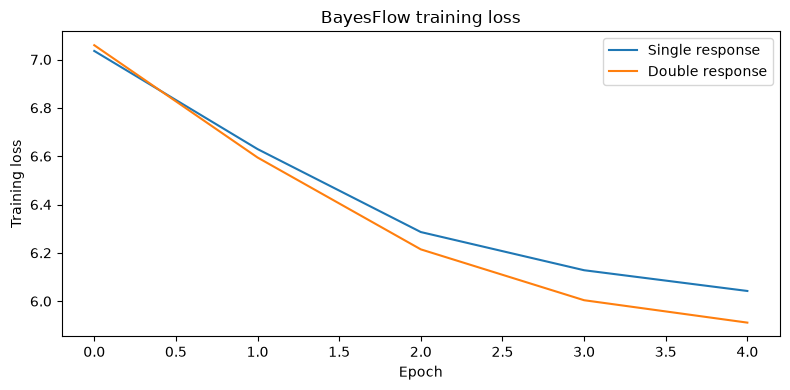

In [ ]:
def plot_training_losses(histories: dict[str, keras.callbacks.History]) -> None:
    """Plot the training losses of multiple BayesFlow workflows."""
    plt.figure(figsize=(8, 4))
    for label, history in histories.items():
        plt.plot(history.history["loss"], label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title("BayesFlow training loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_training_losses({
    "Single response": single_history,
    "Double response": double_history,
})

# Part E — Parameter recovery comparison

## 18. Draw posteriors for the same held-out datasets

Neither workflow has seen these test datasets during training.

In [ ]:
single_posterior = single_workflow.sample(
    conditions=single_test_data,
    num_samples=N_POSTERIOR_SAMPLES,
)

double_posterior = double_workflow.sample(
    conditions=double_test_data,
    num_samples=N_POSTERIOR_SAMPLES,
)

single_samples = np.asarray(single_posterior["parameters"])
double_samples = np.asarray(double_posterior["parameters"])
true_parameters = test_bank["parameters"]

print("Single posterior shape:", single_samples.shape)
print("Double posterior shape:", double_samples.shape)
print("True parameter shape:", true_parameters.shape)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 7.46 seconds.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 0.47 seconds.


Single posterior shape: (40, 250, 5)
Double posterior shape: (40, 250, 5)
True parameter shape: (40, 5)


## 19. Recovery metrics

For each parameter and observation scheme, calculate:

- **RMSE of posterior means:** point-recovery error;
- **normalized RMSE:** RMSE divided by the prior predictive standard deviation;
- **95% coverage:** proportion of true values inside the 95% credible interval;
- **mean interval width:** posterior uncertainty;
- **normalized interval width:** width divided by the prior predictive standard deviation.

A useful double-response result has lower RMSE and/or narrower intervals **without destroying coverage**.

In [ ]:
def compute_recovery_metrics(
    posterior_samples: np.ndarray,
    truth: np.ndarray,
    model_name: str,
    prior_scale: np.ndarray,
) -> pd.DataFrame:
    """Calculate parameter-recovery and uncertainty metrics."""
    posterior_mean = posterior_samples.mean(axis=1)
    lower = np.quantile(posterior_samples, 0.025, axis=1)
    upper = np.quantile(posterior_samples, 0.975, axis=1)

    rows = []
    for j, parameter in enumerate(PARAMETER_NAMES):
        errors = posterior_mean[:, j] - truth[:, j]
        width = upper[:, j] - lower[:, j]
        covered = (truth[:, j] >= lower[:, j]) & (truth[:, j] <= upper[:, j])

        rmse = np.sqrt(np.mean(errors**2))
        rows.append({
            "model": model_name,
            "parameter": parameter,
            "RMSE": rmse,
            "normalized_RMSE": rmse / prior_scale[j],
            "MAE": np.mean(np.abs(errors)),
            "coverage_95": covered.mean(),
            "mean_CI_width": width.mean(),
            "normalized_CI_width": width.mean() / prior_scale[j],
        })

    return pd.DataFrame(rows)

In [ ]:
prior_scale = train_bank["parameters"].std(axis=0, ddof=1)

recovery_metrics = pd.concat(
    [
        compute_recovery_metrics(
            single_samples,
            true_parameters,
            model_name="Single response",
            prior_scale=prior_scale,
        ),
        compute_recovery_metrics(
            double_samples,
            true_parameters,
            model_name="Double response",
            prior_scale=prior_scale,
        ),
    ],
    ignore_index=True,
)

overall_recovery = (
    recovery_metrics
    .groupby("model", as_index=False)
    .agg(
        mean_normalized_RMSE=("normalized_RMSE", "mean"),
        mean_coverage_95=("coverage_95", "mean"),
        mean_normalized_CI_width=("normalized_CI_width", "mean"),
    )
)

overall_recovery

,model,mean_normalized_RMSE,mean_coverage_95,mean_normalized_CI_width
0,Double response,0.855841,0.960,3.191317
1,Single response,0.923910,0.955,3.228143


## 20. Detailed recovery table

Positive values in `RMSE_improvement_percent` mean that the double-response estimator has lower RMSE.

In [ ]:
def build_comparison_table(metrics: pd.DataFrame) -> pd.DataFrame:
    """Put single- and double-response metrics side by side."""
    indexed = metrics.set_index(["parameter", "model"])
    rows = []

    for parameter in PARAMETER_NAMES:
        single = indexed.loc[(parameter, "Single response")]
        double = indexed.loc[(parameter, "Double response")]

        rows.append({
            "parameter": parameter,
            "single_RMSE": single["RMSE"],
            "double_RMSE": double["RMSE"],
            "RMSE_improvement_percent": (
                100 * (single["RMSE"] - double["RMSE"]) / single["RMSE"]
            ),
            "single_coverage_95": single["coverage_95"],
            "double_coverage_95": double["coverage_95"],
            "single_mean_CI_width": single["mean_CI_width"],
            "double_mean_CI_width": double["mean_CI_width"],
        })

    return pd.DataFrame(rows)


comparison_table = build_comparison_table(recovery_metrics)
comparison_table.round(4)

,parameter,single_RMSE,double_RMSE,RMSE_improvement_percent,single_coverage_95,double_coverage_95,single_mean_CI_width,double_mean_CI_width
0,A,0.2201,0.1976,10.2444,1.000,1.000,0.7661,0.7525
1,b,0.3483,0.3226,7.3736,0.900,0.925,1.3311,1.2993
2,t0,0.0584,0.0596,-1.9404,1.000,0.975,0.2074,0.2106
3,v_correct,0.6289,0.4921,21.7406,0.925,0.975,2.0452,2.0108
4,v_error,0.2903,0.2841,2.1478,0.950,0.925,0.9936,0.9740


## 21. Plot normalized RMSE and interval width

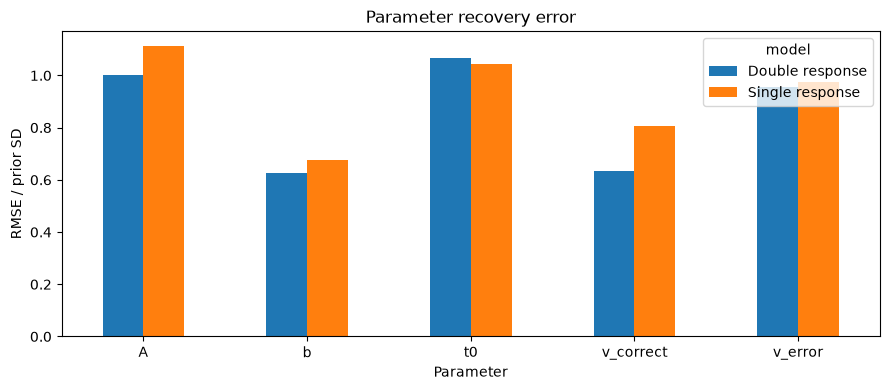

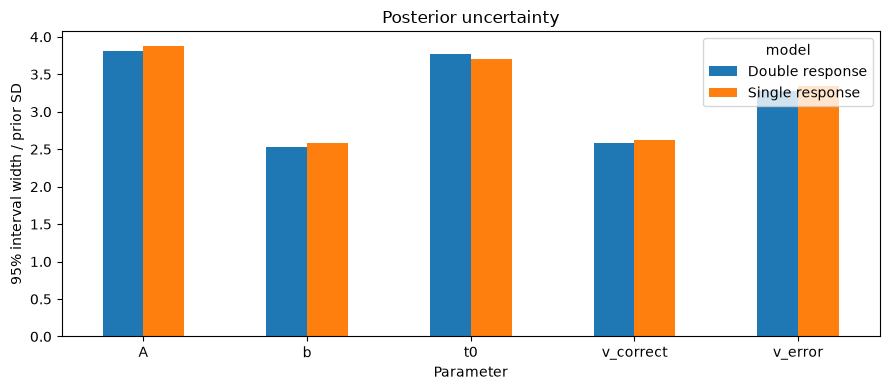

In [ ]:
def plot_metric_comparison(
    metrics: pd.DataFrame,
    metric: str,
    ylabel: str,
    title: str,
) -> None:
    """Create a grouped bar chart for a recovery metric."""
    pivot = metrics.pivot(index="parameter", columns="model", values=metric)
    pivot = pivot.loc[PARAMETER_NAMES]
    ax = pivot.plot(kind="bar", figsize=(9, 4))
    ax.set_xlabel("Parameter")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()


plot_metric_comparison(
    recovery_metrics,
    metric="normalized_RMSE",
    ylabel="RMSE / prior SD",
    title="Parameter recovery error",
)

plot_metric_comparison(
    recovery_metrics,
    metric="normalized_CI_width",
    ylabel="95% interval width / prior SD",
    title="Posterior uncertainty",
)

## 22. Recovery scatterplots

Each point is one held-out synthetic dataset. A point on the diagonal means that the posterior mean equals the true parameter.

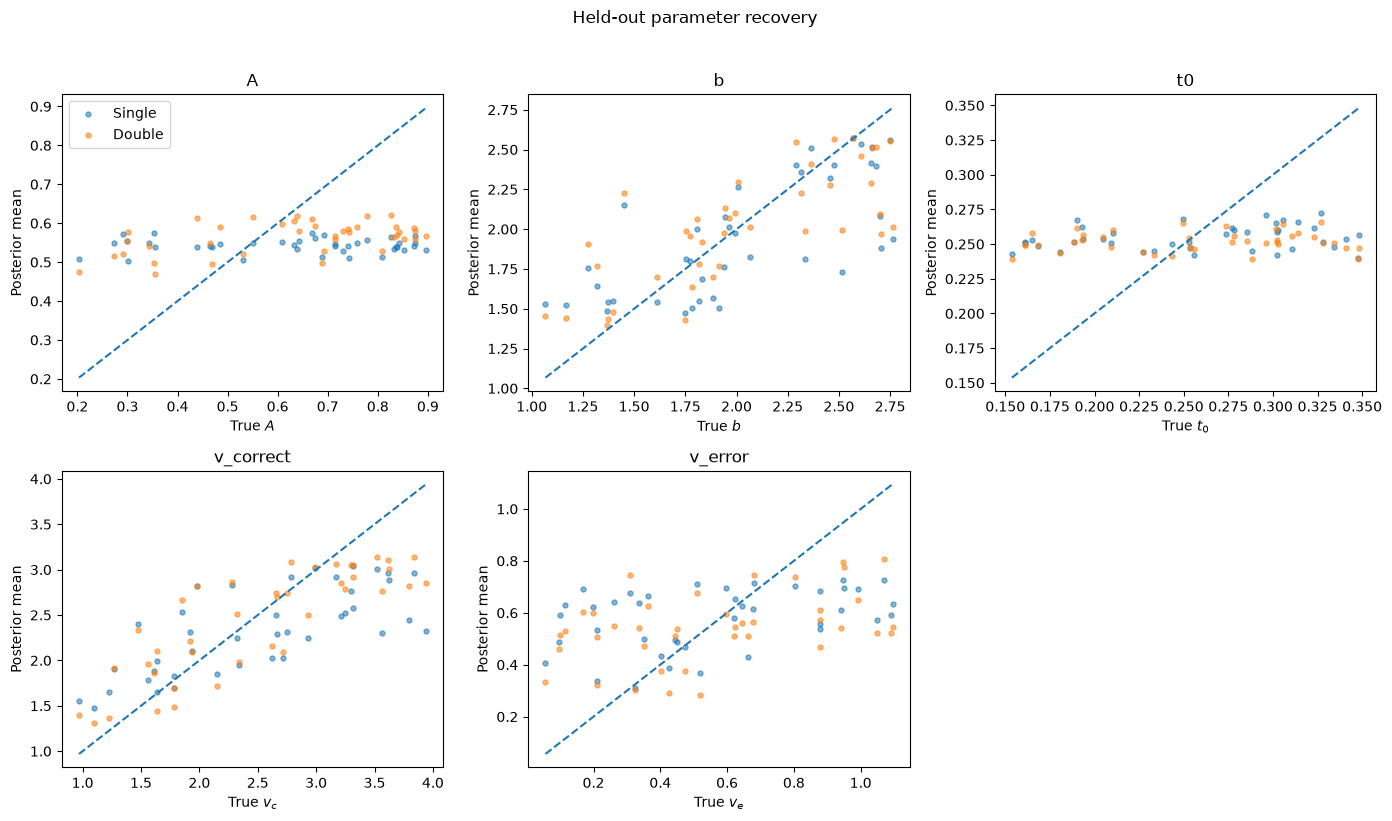

In [ ]:
def plot_recovery_scatter(
    truth: np.ndarray,
    single_posterior_samples: np.ndarray,
    double_posterior_samples: np.ndarray,
) -> None:
    """Compare true values with posterior means for all parameters."""
    single_mean = single_posterior_samples.mean(axis=1)
    double_mean = double_posterior_samples.mean(axis=1)

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()

    for j, (parameter, label) in enumerate(zip(PARAMETER_NAMES, PARAMETER_LABELS)):
        ax = axes[j]
        ax.scatter(truth[:, j], single_mean[:, j], s=13, alpha=0.55, label="Single")
        ax.scatter(truth[:, j], double_mean[:, j], s=13, alpha=0.55, label="Double")

        lower = min(truth[:, j].min(), single_mean[:, j].min(), double_mean[:, j].min())
        upper = max(truth[:, j].max(), single_mean[:, j].max(), double_mean[:, j].max())
        ax.plot([lower, upper], [lower, upper], linestyle="--")
        ax.set_xlabel(f"True {label}")
        ax.set_ylabel("Posterior mean")
        ax.set_title(parameter)

    axes[0].legend()
    axes[-1].axis("off")
    fig.suptitle("Held-out parameter recovery", y=1.02)
    fig.tight_layout()
    plt.show()


plot_recovery_scatter(true_parameters, single_samples, double_samples)

## 23. Examine one synthetic participant in detail

This section shows the posterior means and 95% intervals for one held-out dataset. The true values are known because the dataset was simulated.

In [ ]:
def posterior_summary_for_dataset(
    samples: np.ndarray,
    dataset_id: int,
    model_name: str,
) -> pd.DataFrame:
    """Summarize one dataset's posterior parameter samples."""
    selected = samples[dataset_id]
    return pd.DataFrame({
        "model": model_name,
        "parameter": PARAMETER_NAMES,
        "posterior_mean": selected.mean(axis=0),
        "lower_95": np.quantile(selected, 0.025, axis=0),
        "upper_95": np.quantile(selected, 0.975, axis=0),
    })


DATASET_ID = 0

one_dataset_summary = pd.concat(
    [
        posterior_summary_for_dataset(single_samples, DATASET_ID, "Single response"),
        posterior_summary_for_dataset(double_samples, DATASET_ID, "Double response"),
    ],
    ignore_index=True,
)
one_dataset_summary["true_value"] = np.tile(true_parameters[DATASET_ID], 2)
one_dataset_summary.round(4)

,model,parameter,posterior_mean,lower_95,upper_95,true_value
0,Single response,A,0.5643,0.1604,0.9093,0.8258
1,Single response,b,1.9991,1.1511,2.6840,1.8080
2,Single response,t0,0.2588,0.1549,0.3744,0.3020
3,Single response,v_correct,2.2912,1.2441,3.3129,2.6651
4,Single response,v_error,0.5897,0.0657,1.1091,0.0992
5,Double response,A,0.6209,0.2594,0.9666,0.8258
6,Double response,b,2.0661,1.4172,2.6482,1.8080
7,Double response,t0,0.2517,0.1479,0.3598,0.3020
8,Double response,v_correct,2.7028,1.7134,3.5899,2.6651
9,Double response,v_error,0.5125,-0.0033,1.0116,0.0992


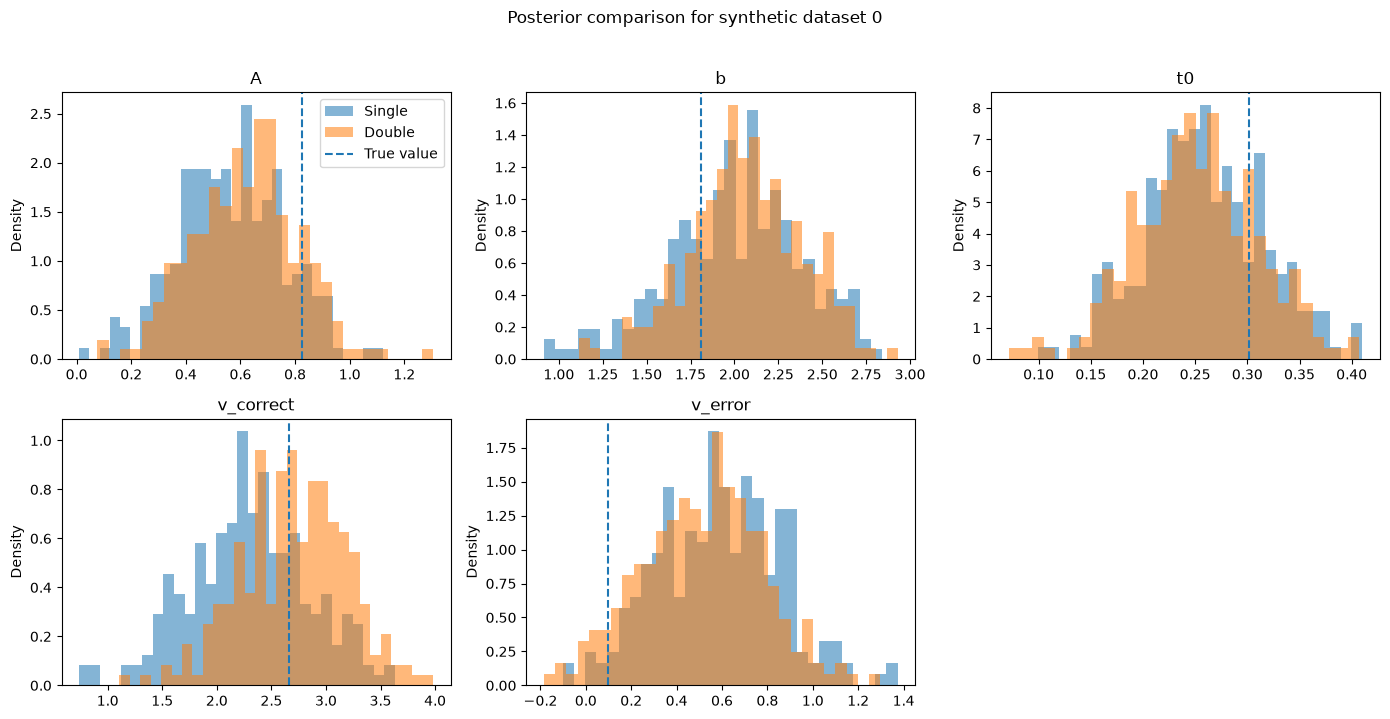

In [ ]:
def plot_one_dataset_posteriors(
    truth: np.ndarray,
    single_posterior_samples: np.ndarray,
    double_posterior_samples: np.ndarray,
    dataset_id: int,
) -> None:
    """Overlay posterior marginals for one synthetic dataset."""
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    axes = axes.ravel()

    for j, parameter in enumerate(PARAMETER_NAMES):
        ax = axes[j]
        ax.hist(
            single_posterior_samples[dataset_id, :, j],
            bins=30,
            density=True,
            alpha=0.55,
            label="Single",
        )
        ax.hist(
            double_posterior_samples[dataset_id, :, j],
            bins=30,
            density=True,
            alpha=0.55,
            label="Double",
        )
        ax.axvline(truth[dataset_id, j], linestyle="--", label="True value")
        ax.set_title(parameter)
        ax.set_ylabel("Density")

    axes[0].legend()
    axes[-1].axis("off")
    fig.suptitle(f"Posterior comparison for synthetic dataset {dataset_id}", y=1.02)
    fig.tight_layout()
    plt.show()


plot_one_dataset_posteriors(
    true_parameters,
    single_samples,
    double_samples,
    DATASET_ID,
)

# Part F — Interpretation

## 24. How to read the result

Focus on three questions:

1. **Recovery:** Is double-response normalized RMSE lower, particularly for the losing/error accumulator drift \(v_e\)?
2. **Uncertainty:** Are double-response intervals narrower?
3. **Calibration:** Does 95% coverage remain reasonably close to 0.95?

Double responses are expected to be especially informative about the **losing accumulator**. Initial choice and RT are dominated by the winner, while a double response directly reveals that the loser was close enough to reach its threshold soon afterwards.

Do not conclude that the double-response estimator is better merely because its intervals are narrower. Narrow intervals are useful only when recovery and coverage remain acceptable.

In [ ]:
def automatic_conclusion(comparison: pd.DataFrame) -> str:
    """Generate a cautious text summary from the recovery table."""
    mean_improvement = comparison["RMSE_improvement_percent"].mean()
    best_row = comparison.loc[comparison["RMSE_improvement_percent"].idxmax()]
    worse_count = int((comparison["RMSE_improvement_percent"] < 0).sum())

    return (
        f"Average RMSE improvement from double-response information: "
        f"{mean_improvement:.1f}%. The largest improvement is for "
        f"{best_row['parameter']} ({best_row['RMSE_improvement_percent']:.1f}%). "
        f"Double-response recovery is worse for {worse_count} of "
        f"{len(comparison)} parameters. Check coverage before interpreting "
        f"narrower intervals as better inference."
    )


print(automatic_conclusion(comparison_table))

Average RMSE improvement from double-response information: 7.9%. The largest improvement is for v_correct (21.7%). Double-response recovery is worse for 1 of 5 parameters. Check coverage before interpreting narrower intervals as better inference.


# Part G — Optional real-participant illustration

This is **not required** for the parameter-recovery goal.

The simplified simulator is not guaranteed to fit the real participant, and the real double-response rates are lower than much of the teaching prior-predictive distribution. Therefore, this section should be treated as a demonstration of how amortized inference is applied, not as a publishable empirical analysis.

The code:

- selects one participant;
- excludes first RTs below 250 ms, matching the paper's fitting exclusion;
- draws a random subset with the same number of trials used during training;
- applies both already-trained workflows.

In [ ]:
RUN_REAL_DATA_EXAMPLE = True
REAL_PARTICIPANT_ID = 1  # values 1 to 4

In [ ]:
def prepare_real_participant_conditions(
    r_object: dict,
    participant_id: int,
    n_trials: int,
    seed: int,
) -> tuple[dict[str, np.ndarray], dict[str, np.ndarray], pd.Series]:
    """Prepare one real participant for the two trained workflows."""
    if not 1 <= participant_id <= len(r_object["data"]):
        raise ValueError("participant_id is outside the available range.")

    participant = r_object["data"][participant_id - 1]
    correct = np.asarray(participant["Correct"], dtype=bool)
    rt = np.asarray(participant["Time1"], dtype=float)
    double = np.asarray(participant["DoubleResp"], dtype=bool)
    latency = np.asarray(participant["Time2"], dtype=float)

    valid = np.isfinite(rt) & (rt >= 0.250)
    valid_indices = np.flatnonzero(valid)
    if len(valid_indices) < n_trials:
        raise ValueError("Not enough valid trials for the requested subset size.")

    rng = np.random.default_rng(seed)
    selected = rng.choice(valid_indices, size=n_trials, replace=False)

    single = np.column_stack([
        correct[selected].astype(np.float32),
        rt[selected].astype(np.float32),
    ])
    double_data = np.column_stack([
        correct[selected].astype(np.float32),
        rt[selected].astype(np.float32),
        double[selected].astype(np.float32),
        np.where(double[selected], latency[selected], 0.0).astype(np.float32),
    ])

    descriptive = summarize_trials(double_data)
    return (
        {"observations": single[None, :, :]},
        {"observations": double_data[None, :, :]},
        descriptive,
    )

In [ ]:
if RUN_REAL_DATA_EXAMPLE:
    if RDATA_PATH is None:
        raise FileNotFoundError("Place parsedData_doubleResp.Rdata beside the notebook.")

    if "evans_rdata" not in globals():
        evans_rdata = load_evans_rdata(RDATA_PATH)

    real_single_conditions, real_double_conditions, real_description = (
        prepare_real_participant_conditions(
            r_object=evans_rdata,
            participant_id=REAL_PARTICIPANT_ID,
            n_trials=N_TRIALS,
            seed=SEED + 50,
        )
    )

    display(real_description.to_frame("value"))

    real_single_posterior = single_workflow.sample(
        conditions=real_single_conditions,
        num_samples=N_POSTERIOR_SAMPLES,
    )
    real_double_posterior = double_workflow.sample(
        conditions=real_double_conditions,
        num_samples=N_POSTERIOR_SAMPLES,
    )

    real_single_samples = np.asarray(real_single_posterior["parameters"])
    real_double_samples = np.asarray(real_double_posterior["parameters"])

    real_table = pd.concat([
        posterior_summary_for_dataset(real_single_samples, 0, "Single response"),
        posterior_summary_for_dataset(real_double_samples, 0, "Double response"),
    ])
    display(real_table.round(4))
else:
    print("Real-data inference is disabled. Set RUN_REAL_DATA_EXAMPLE=True after training.")

,value
n_trials,300.000000
accuracy,0.693333
mean_RT_s,0.436966
median_RT_s,0.420200
double_response_rate,0.013333
P(DR | correct),0.000000
P(DR | error),0.043478
median_DR_latency_s,0.146050


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 6.87 seconds.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 0.27 seconds.


,model,parameter,posterior_mean,lower_95,upper_95
0,Single response,A,0.5060,0.1446,0.8753
1,Single response,b,1.4829,0.6420,2.2436
2,Single response,t0,0.2485,0.1499,0.3592
3,Single response,v_correct,3.0121,1.6377,4.2691
4,Single response,v_error,0.7222,0.2323,1.2187
0,Double response,A,0.4879,0.1179,0.9210
1,Double response,b,1.4978,0.6598,2.4283
2,Double response,t0,0.2508,0.1123,0.3735
3,Double response,v_correct,2.7294,1.5551,3.8271
4,Double response,v_error,0.7524,0.2779,1.2839


# Part H — Recommended extensions

After the basic notebook works, useful extensions are:

1. Increase the number of simulations, epochs, and trials.
2. Repeat training with several random seeds to ensure the result is not a lucky neural-network run.
3. Compare recovery at several trial counts, such as 100, 300, 1,000, and 10,000.
4. Include between-trial drift or non-decision-time variability.
5. Extend the independent RDM with a competitive mechanism such as lateral inhibition and evaluate whether it better reproduces empirical double-response behavior.
6. Add posterior predictive checks for RT distributions and conditional double-response rates.
7. Train on priors calibrated more closely to the empirical participants before attempting substantive real-data inference.

# Final Project Statement

This notebook evaluates the following hypothesis:

$$
\text{Adding double-response observations}
\quad \stackrel{?}{\Longrightarrow} \quad
\text{improved recovery of RDM parameters}
$$

The comparison is controlled because the two BayesFlow systems use:

- the same prior,
- the same scientific simulator,
- the same latent parameter targets,
- the same training and test parameter draws,
- the same neural-network architecture,

and differ only in the **observed trial-level information** provided to the summary network.

The **single-response estimator** receives:

$$
(\mathrm{correct},\, RT)
$$

whereas the **double-response estimator** receives:

$$
(\mathrm{correct},\, RT,\, DR,\, DRT)
$$

where:

- $RT$ = first-response time,
- $DR$ = double-response indicator,
- $DRT$ = double-response latency.

Parameter recovery on **held-out synthetic datasets** is then used to determine whether including double-response information improves inference of the underlying RDM parameters.

## BayesFlow references

- BayesFlow documentation: https://bayesflow.org/
- BayesFlow 2 tutorial examples: https://bayesflow.org/v2.0.12/examples.html
- Kühmichel et al. (2026), *BayesFlow 2: Multi-backend amortized Bayesian inference in Python*: https://arxiv.org/abs/2602.07098